In [40]:
#system
import psutil
import time
import csv
import os
import sqlite3
import shutil
from datetime import datetime, timedelta

#data wrangling
import pandas as pd
from urllib.parse import urlparse
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#clustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

#deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Ram Data Collection

In [41]:
def log_ram(interval=5, output_file='ram_log.csv'):
    # Write header if file doesn't exist
    file_exists = os.path.isfile(output_file)

    print(f"Starting RAM logger. Interval: {interval}s. Logging to {output_file}...")
    print("Press Ctrl+C to stop.")

    try:
        with open(output_file, 'a', newline='') as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(['timestamp', 'total_mb', 'used_mb', 'available_mb', 'usage_percent'])

            while True:
                mem = psutil.virtual_memory()
                timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

                # Convert bytes to MB
                total = round(mem.total / (1024**2), 2)
                used = round(mem.used / (1024**2), 2)
                available = round(mem.available / (1024**2), 2)
                percent = mem.percent

                writer.writerow([timestamp, total, used, available, percent])
                f.flush() # Ensure data is written to disk

                time.sleep(interval)
    except KeyboardInterrupt:
        print("\nLogging stopped by user.")

if __name__ == "__main__":
    log_ram()

Starting RAM logger. Interval: 5s. Logging to ram_log.csv...
Press Ctrl+C to stop.

Logging stopped by user.


# Chrome Data Collection

In [42]:
def extract_chrome_history():

    history_path = os.path.expanduser("~/.config/google-chrome/Default/History")

    if not os.path.exists(history_path):
        print("Chrome History file not found at the standard location.")
        print("Please manually update the 'history_path' variable in the script.")
        return

    # Create a temporary copy to avoid "Database locked" error if Chrome is open
    temp_history = "temp_chrome_history"
    shutil.copy2(history_path, temp_history)

    try:
        conn = sqlite3.connect(temp_history)
        query = """
        SELECT
            datetime(last_visit_time/1000000-11644473600, 'unixepoch', 'localtime') as timestamp,
            url,
            title
        FROM urls
        ORDER BY last_visit_time DESC
        """
        df = pd.read_csv(conn.execute(query))

        df = pd.read_sql_query(query, conn)

        # Save to CSV
        output_file = 'browsing_history.csv'
        df.to_csv(output_file, index=False)
        print(f"Successfully extracted {len(df)} records to {output_file}")

    except Exception as e:
        print(f"Error: {e}")
    finally:
        conn.close()
        if os.path.exists(temp_history):
            os.remove(temp_history)

if __name__ == "__main__":
    extract_chrome_history()

Chrome History file not found at the standard location.
Please manually update the 'history_path' variable in the script.


In [43]:
chrome_data = pd.read_csv('browsing_history_last5days.csv')
ram_data = pd.read_csv('ram_log_last5days.csv')

In [44]:
chrome_data.shape, ram_data.shape

((24321, 7), (103680, 5))

# Data Preprocessing


In [45]:
# 1. Clean URL and extract domain, remove sensitive URL parts (query strings)
def clean_and_extract_url_parts(url):
    try:
        parsed_url = urlparse(url)
        # Reconstruct URL without query string and fragment for cleaning
        cleaned_url = parsed_url.scheme + "://" + parsed_url.netloc + parsed_url.path
        # Extract domain from the netloc part, removing 'www.'
        domain = parsed_url.netloc.replace('www.', '')
        return cleaned_url, domain
    except Exception:
        # If parsing fails, return original URL and NaN for domain
        return url, np.nan

# Apply the cleaning and domain extraction. pd.Series is used to assign multiple outputs to new columns.
chrome_data[['cleaned_url', 'domain']] = chrome_data['url'].apply(lambda x: pd.Series(clean_and_extract_url_parts(x)))

# 2. Map domain → category using a curated mapping table
domain_to_category_mapping = {
    'google.com': 'Search/Reference',
    'www.google.com': 'Search/Reference',
    'youtube.com': 'Social Media',
    'm.youtube.com': 'Social Media',
    'instagram.com': 'Social Media',
    'facebook.com': 'Social Media',
    'twitter.com': 'Social Media',
    'x.com': 'Social Media',
    'reddit.com': 'Social Media',
    'linkedin.com': 'Social Media',
    'github.com': 'Search/Reference',
    'stackoverflow.com': 'Search/Reference',
    'wikipedia.org': 'Search/Reference',
    'medium.com': 'Learning/Education',
    'docs.google.com': 'Learning/Education',
    'drive.google.com': 'Productivity/Work',
    'colab.research.google.com': 'Learning/Education',
    'amazon.in': 'Shopping',
    'amazon.com': 'Shopping',
    'flipkart.com': 'Shopping',
    'blinkit.com': 'Shopping',
    'myntra.com': 'Shopping',
    'meesho.com': 'Shopping',
    'jiomart.com': 'Shopping',
    'netflix.com': 'Entertainment/Media',
    'spotify.com': 'Entertainment/Media',
    'hotstar.com': 'Entertainment/Media',
    'primevideo.com': 'Entertainment/Media',
    'slack.com': 'Productivity/Work',
    'zoom.us': 'Productivity/Work',
    'outlook.live.com': 'Productivity/Work',
    'mail.google.com': 'Productivity/Work',
    'jetbrains.com': 'Productivity/Work',
    'dbeaver.io': 'Productivity/Work',
    'kaggle.com': 'Learning/Education',
    'geeksforgeeks.org': 'Learning/Education',
    'w3schools.com': 'Learning/Education',
    'tutorialspoint.com': 'Learning/Education',
    'javatpoint.com': 'Learning/Education',
    'leetcode.com': 'Learning/Education',
    'hackerrank.com': 'Learning/Education',
    'openai.com': 'Search/Reference',
    'chat.openai.com': 'Search/Reference',
    'claude.ai': 'Search/Reference',
    'gemini.google.com': 'Search/Reference',
}

# Function to map domain to category, defaulting to 'Other' if not found
def map_domain_to_category(domain):
    # Handle NaN domains that might result from URL parsing errors
    if pd.isna(domain):
        return np.nan
    return domain_to_category_mapping.get(domain, 'Other')

chrome_data['category'] = chrome_data['domain'].apply(map_domain_to_category)

# 3. Convert timestamps and create hour, date, day_name
chrome_data['timestamp'] = pd.to_datetime(chrome_data['timestamp'])

# Create new columns based on the processed 'timestamp'
chrome_data['hour'] = chrome_data['timestamp'].dt.hour
chrome_data['date'] = chrome_data['timestamp'].dt.date
chrome_data['day_name'] = chrome_data['timestamp'].dt.day_name()

print("Processed `chrome_data` head after preprocessing:")
print(chrome_data[['timestamp', 'domain', 'category', 'hour', 'date', 'day_name']].head())
print("\nValue counts for the new 'category' column (top 5):")
print(chrome_data['category'].value_counts().head())

Processed `chrome_data` head after preprocessing:
   timestamp            domain            category  hour        date day_name
0 2026-07-27   docs.google.com  Learning/Education     0  2026-07-27   Monday
1 2026-07-27   docs.google.com  Learning/Education     0  2026-07-27   Monday
2 2026-07-27   docs.google.com  Learning/Education     0  2026-07-27   Monday
3 2026-07-27   docs.google.com  Learning/Education     0  2026-07-27   Monday
4 2026-07-27  drive.google.com   Productivity/Work     0  2026-07-27   Monday

Value counts for the new 'category' column (top 5):
category
Search/Reference      10836
Social Media           5639
Other                  5402
Learning/Education     1763
Productivity/Work       379
Name: count, dtype: int64


## Evaluation Metrics: Data Pipeline Quality

This section evaluates the quality of the data pipeline, focusing on the completeness of history extraction, accuracy of URL/domain parsing, and correctness of sessionization.

In [46]:
initial_records = chrome_data.shape[0]
cleaned_records = chrome_data.dropna(subset=['url', 'domain', 'category', 'timestamp']).shape[0]
parsing_completeness = (cleaned_records / initial_records) * 100 if initial_records > 0 else 0

print(f"History Extraction Completeness: {parsing_completeness:.2f}% of records have complete URL, domain, category, and timestamp information.")

History Extraction Completeness: 100.00% of records have complete URL, domain, category, and timestamp information.


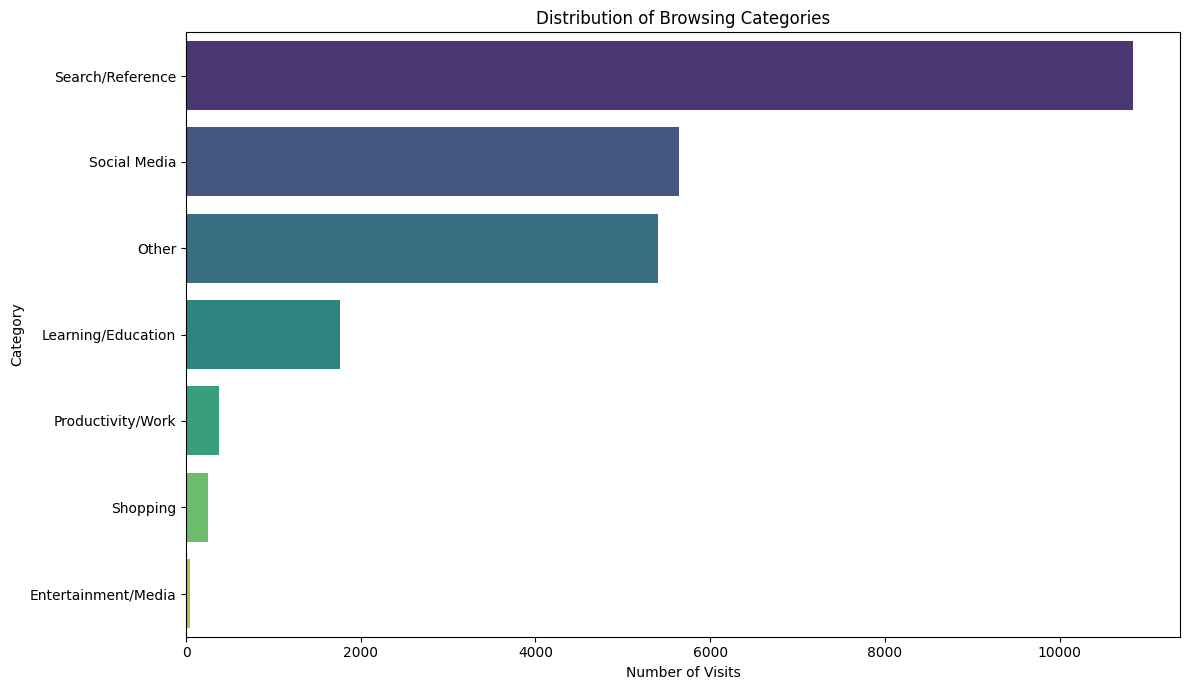

In [47]:
category_counts = chrome_data['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

plt.figure(figsize=(12, 7))
sns.barplot(x='count', y='category', data=category_counts, palette='viridis',hue = 'category')
plt.title('Distribution of Browsing Categories')
plt.xlabel('Number of Visits')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Sessionization

In [48]:
chrome_data = chrome_data.sort_values(by='timestamp').reset_index(drop=True)

inactivity_threshold_seconds = 2.2 * 60
chrome_data['time_diff'] = chrome_data['timestamp'].diff().dt.total_seconds()
chrome_data['new_session'] = (chrome_data['time_diff'] > inactivity_threshold_seconds) | (chrome_data['time_diff'].isna())

# Assign session IDs
chrome_data['session_id'] = chrome_data['new_session'].cumsum()

# Calculate summary statistics for each session
session_summary_df = chrome_data.groupby('session_id').agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max'),
    page_count=('url', 'count'),
    unique_domains=('domain', lambda x: x.nunique()),
    unique_categories=('category', lambda x: x.nunique()),
    primary_category=('category', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Calculate session duration
session_summary_df['session_duration_minutes'] = (session_summary_df['session_end'] - session_summary_df['session_start']).dt.total_seconds() / 60

# Calculate domain and category switches within a session
def calculate_switches(series):
    return (series != series.shift(1)).sum() - 1
session_switches = chrome_data.groupby('session_id').agg(
    domain_switches=('domain', calculate_switches),
    category_switches=('category', calculate_switches)
).reset_index()

# Merge switches back into the session summary
session_summary_df = pd.merge(session_summary_df, session_switches, on='session_id', how='left')

# Ensure switches are not negative for sessions with 0 or 1 entry
session_summary_df['domain_switches'] = session_summary_df['domain_switches'].clip(lower=0)
session_summary_df['category_switches'] = session_summary_df['category_switches'].clip(lower=0)

# Calculate average time per page
session_summary_df['avg_time_per_page_seconds'] = (session_summary_df['session_duration_minutes'] * 60) / session_summary_df['page_count']

print(chrome_data[['timestamp', 'domain', 'session_id', 'time_diff', 'new_session']].head())
print(f"\nTotal number of sessions identified: {len(session_summary_df)}\n")
display(session_summary_df.head())


   timestamp            domain  session_id  time_diff  new_session
0 2026-07-27   docs.google.com           1        NaN         True
1 2026-07-27     jetbrains.com           1        0.0        False
2 2026-07-27     jetbrains.com           1        0.0        False
3 2026-07-27        google.com           1        0.0        False
4 2026-07-27  drive.google.com           1        0.0        False

Total number of sessions identified: 51



,session_id,session_start,session_end,page_count,unique_domains,unique_categories,primary_category,session_duration_minutes,domain_switches,category_switches,avg_time_per_page_seconds
0,1,2026-07-27 00:00:00,2026-07-27 04:45:15,810,35,5,Other,285.250000,159,94,21.129630
1,2,2026-07-27 04:47:32,2026-07-27 06:28:02,285,24,5,Search/Reference,100.500000,68,27,21.157895
2,3,2026-07-27 06:30:29,2026-07-27 10:19:28,666,32,6,Search/Reference,228.983333,83,64,20.629129
3,4,2026-07-27 10:22:02,2026-07-27 10:22:09,2,1,1,Search/Reference,0.116667,0,0,3.500000
4,5,2026-07-27 10:24:53,2026-07-27 10:26:45,7,2,2,Social Media,1.866667,1,1,16.000000


## Evaluation Metrics: Sessionization Correctness

Sessionization correctness is verified by manually inspecting a sample of sessions to ensure events are grouped logically based on the defined inactivity threshold.

In [49]:
# Sessionization correctness (manual verification for 20–50 events)
print("Sessionization Correctness: Manual verification is crucial. Below is an example of how to inspect a few sessions.")
print("Please manually review the 'timestamp', 'url', and 'session_id' for a few chosen sessions.")

# Display events for a few random sessions for manual review
sample_session_ids = session_summary_df['session_id'].sample(min(5, len(session_summary_df)), random_state=42).tolist()

for session_id in sample_session_ids:
    print(f"\n--- Session ID: {session_id} ---")
    display(chrome_data[chrome_data['session_id'] == session_id][['timestamp', 'url', 'category', 'time_diff']].head(10))

Sessionization Correctness: Manual verification is crucial. Below is an example of how to inspect a few sessions.
Please manually review the 'timestamp', 'url', and 'session_id' for a few chosen sessions.

--- Session ID: 44 ---


,timestamp,url,category,time_diff
21152,2026-08-01 05:15:18,https://www.google.com/search?q=latest+malayal...,Search/Reference,227.0
21153,2026-08-01 05:15:32,https://www.google.com/search?q=latest+malayal...,Search/Reference,14.0
21154,2026-08-01 05:15:33,https://www.google.com/search?q=latest+malayal...,Search/Reference,1.0
21155,2026-08-01 05:15:34,https://www.google.com/search?q=latest+malayal...,Search/Reference,1.0
21156,2026-08-01 05:15:54,https://www.google.com/search?q=latest+malayal...,Search/Reference,20.0
21157,2026-08-01 05:17:50,https://www.google.com/search?q=latest+malayal...,Search/Reference,116.0
21158,2026-08-01 05:17:51,https://www.google.com/search?q=latest+malayal...,Search/Reference,1.0
21159,2026-08-01 05:18:47,https://www.google.com/search?q=latest+malayal...,Search/Reference,56.0
21160,2026-08-01 05:19:18,https://www.google.com/search?q=latest+malayal...,Search/Reference,31.0
21161,2026-08-01 05:19:21,https://www.google.com/search?q=latest+malayal...,Search/Reference,3.0



--- Session ID: 41 ---


,timestamp,url,category,time_diff
19113,2026-07-31 17:12:37,https://m.youtube.com/results?sp=mAEA&search_q...,Social Media,211.0
19114,2026-07-31 17:12:38,https://m.youtube.com/results?sp=mAEA&search_q...,Social Media,1.0
19115,2026-07-31 17:12:55,https://m.youtube.com/results?sp=mAEA&search_q...,Social Media,17.0
19116,2026-07-31 17:13:32,https://m.youtube.com/watch?v=jmORTJbIzww#sear...,Social Media,37.0
19117,2026-07-31 17:14:20,https://m.youtube.com/watch?v=jmORTJbIzww,Social Media,48.0
19118,2026-07-31 17:15:04,https://m.youtube.com/watch?v=jmORTJbIzww,Social Media,44.0
19119,2026-07-31 17:15:10,https://m.youtube.com/watch?v=FrXJMvw51IE&pp=0...,Social Media,6.0
19120,2026-07-31 17:15:21,https://m.youtube.com/watch?v=g_f9k0s2Jz0&pp=y...,Social Media,11.0
19121,2026-07-31 17:15:52,https://m.youtube.com/results?sp=mAEA&search_q...,Social Media,31.0
19122,2026-07-31 17:16:17,https://m.youtube.com/watch?v=1tOZjUy_8es&pp=y...,Social Media,25.0



--- Session ID: 47 ---


,timestamp,url,category,time_diff
22913,2026-08-01 15:38:56,https://www.instagram.com/,Social Media,145.0
22914,2026-08-01 15:40:01,https://www.google.com/search?q=madha+sarbinma...,Search/Reference,65.0
22915,2026-08-01 15:40:25,https://frame.work/products/laptop16-diy-amd-a...,Other,24.0
22916,2026-08-01 15:40:40,https://www.google.com/search?q=companies+like...,Search/Reference,15.0
22917,2026-08-01 15:40:52,https://frame.work/products/laptop16-diy-amd-a...,Other,12.0
22918,2026-08-01 15:41:13,https://frame.work/products/laptop16-diy-amd-a...,Other,21.0
22919,2026-08-01 15:41:25,https://www.instagram.com/reel/DX9CZ11jLem/?ig...,Social Media,12.0
22920,2026-08-01 15:41:46,https://www.instagram.com/direct/t/16838233929...,Social Media,21.0
22921,2026-08-01 15:41:50,https://www.instagram.com/reels/audio/26605285...,Social Media,4.0
22922,2026-08-01 15:42:04,https://www.instagram.com/direct/t/16838233929...,Social Media,14.0



--- Session ID: 13 ---


,timestamp,url,category,time_diff
4422,2026-07-28 02:13:01,https://docs.google.com/document/d/1Iizn8qG2BB...,Learning/Education,164.0
4423,2026-07-28 02:13:43,https://colab.research.google.com/drive/19mGSM...,Learning/Education,42.0
4424,2026-07-28 02:13:51,https://colab.research.google.com/drive/19mGSM...,Learning/Education,8.0
4425,2026-07-28 02:14:37,https://colab.research.google.com/drive/19mGSM...,Learning/Education,46.0
4426,2026-07-28 02:14:56,https://colab.research.google.com/drive/19mGSM...,Learning/Education,19.0
4427,2026-07-28 02:15:02,https://colab.research.google.com/drive/19mGSM...,Learning/Education,6.0
4428,2026-07-28 02:15:07,https://colab.research.google.com/drive/19mGSM...,Learning/Education,5.0
4429,2026-07-28 02:15:25,https://colab.research.google.com/drive/19mGSM...,Learning/Education,18.0
4430,2026-07-28 02:16:02,https://colab.research.google.com/drive/19mGSM...,Learning/Education,37.0
4431,2026-07-28 02:16:17,https://colab.research.google.com/drive/19mGSM...,Learning/Education,15.0



--- Session ID: 25 ---


,timestamp,url,category,time_diff
8712,2026-07-29 03:34:06,https://www.instagram.com/nithyessri/reel/DapJ...,Social Media,133.0
8713,2026-07-29 03:34:17,https://www.instagram.com/nithyessri/,Social Media,11.0
8714,2026-07-29 03:34:28,https://www.instagram.com/stories/nithyessri/3...,Social Media,11.0
8715,2026-07-29 03:34:42,https://www.instagram.com/stories/nithyessri/,Social Media,14.0
8716,2026-07-29 03:35:24,https://www.instagram.com/nithyessri/,Social Media,42.0
8717,2026-07-29 03:35:44,https://www.instagram.com/explore/search/,Social Media,20.0
8718,2026-07-29 03:35:47,https://www.instagram.com/explore/,Social Media,3.0
8719,2026-07-29 03:35:56,https://www.instagram.com/p/Dau2QSKzz6R/,Social Media,9.0
8720,2026-07-29 03:36:45,https://www.instagram.com/explore/,Social Media,49.0
8721,2026-07-29 03:38:05,https://www.instagram.com/,Social Media,80.0


In [50]:
print("\nUnique values and their counts from the 'timestamp' column (top 10):")
print(chrome_data['timestamp'].value_counts().head(10))

print("\nDescriptive statistics for 'time_diff' (excluding NaNs for the first entry):")
print(chrome_data['time_diff'].dropna().describe())

print("\nNumber of events with time_diff == 0:")
print(chrome_data[chrome_data['time_diff'] == 0].shape[0])

print("\nNumber of new sessions identified (should be > 1 if timestamps are correct):")
print(chrome_data['new_session'].sum())


Unique values and their counts from the 'timestamp' column (top 10):
timestamp
2026-08-01 23:59:59    23
2026-07-27 00:00:00    11
2026-08-01 06:04:11     3
2026-07-30 13:01:03     3
2026-08-01 08:19:37     3
2026-07-29 02:23:45     3
2026-07-31 12:17:53     3
2026-07-30 20:01:51     3
2026-08-01 13:00:12     3
2026-07-29 00:18:44     2
Name: count, dtype: int64

Descriptive statistics for 'time_diff' (excluding NaNs for the first entry):
count    24320.000000
mean        21.315748
std         21.306608
min          0.000000
25%          6.000000
50%         15.000000
75%         30.000000
max        227.000000
Name: time_diff, dtype: float64

Number of events with time_diff == 0:
588

Number of new sessions identified (should be > 1 if timestamps are correct):
51


# Ram Correlation

In [51]:
# 1. Prepare ram_data: Convert timestamp to datetime and sort
ram_data['timestamp'] = pd.to_datetime(ram_data['timestamp'])
ram_data = ram_data.sort_values(by='timestamp').reset_index(drop=True)

# 2. Join browsing events with RAM logs using nearest timestamp merge
merged_data = pd.merge_asof(
    chrome_data,
    ram_data,
    on='timestamp',
    direction='backward', # Use the RAM log entry at or before the browsing event
    suffixes=('_chrome', '_ram')
)

print("\nMerged data (chrome_data + ram_data, first 5 rows):\n")
display(merged_data[['timestamp', 'domain', 'session_id', 'category', 'used_mb', 'usage_percent']].head())

# 3. Produce RAM stats per session
session_ram_stats = merged_data.groupby('session_id').agg(
    mean_used_mb=('used_mb', 'mean'),
    peak_used_mb=('used_mb', 'max'),
    mean_usage_percent=('usage_percent', 'mean'),
    peak_usage_percent=('usage_percent', 'max')
).reset_index()

print("\nRAM Stats per Session (first 5 rows):\n")
display(session_ram_stats.head())

# 4. Produce RAM stats per category
category_ram_stats = merged_data.groupby('category').agg(
    mean_used_mb=('used_mb', 'mean'),
    peak_used_mb=('used_mb', 'max'),
    mean_usage_percent=('usage_percent', 'mean'),
    peak_usage_percent=('usage_percent', 'max')
).reset_index()

print("\nRAM Stats per Category (all categories):\n")
display(category_ram_stats)



Merged data (chrome_data + ram_data, first 5 rows):



,timestamp,domain,session_id,category,used_mb,usage_percent
0,2026-07-27,docs.google.com,1,Learning/Education,3522.0,42.99
1,2026-07-27,jetbrains.com,1,Productivity/Work,3522.0,42.99
2,2026-07-27,jetbrains.com,1,Productivity/Work,3522.0,42.99
3,2026-07-27,google.com,1,Search/Reference,3522.0,42.99
4,2026-07-27,drive.google.com,1,Productivity/Work,3522.0,42.99



RAM Stats per Session (first 5 rows):



,session_id,mean_used_mb,peak_used_mb,mean_usage_percent,peak_usage_percent
0,1,3458.734198,5383.0,42.220790,65.71
1,2,3787.875439,4563.0,46.238596,55.70
2,3,4695.921622,5987.8,57.323198,73.09
3,4,6471.350000,6564.0,78.995000,80.13
4,5,5449.442857,5871.0,66.521429,71.67



RAM Stats per Category (all categories):



,category,mean_used_mb,peak_used_mb,mean_usage_percent,peak_usage_percent
0,Entertainment/Media,4476.973333,6228.2,54.651556,76.03
1,Learning/Education,4230.581792,6947.9,51.642830,84.81
2,Other,4544.361218,6985.7,55.473177,85.27
3,Productivity/Work,4434.503694,6888.0,54.132216,84.08
4,Search/Reference,4610.088824,7534.7,56.275490,91.98
5,Shopping,4266.050195,6551.6,52.075953,79.98
6,Social Media,4774.954797,7555.9,58.288026,92.24


## Evaluation Metrics: RAM Analysis

This section evaluates the RAM usage patterns derived from the browsing data.

In [52]:
print("\nCategory-wise RAM Statistics:")
display(category_ram_stats.sort_values(by='peak_usage_percent', ascending=False))

# Identify top 3 memory-heavy categories/domains
top_3_memory_heavy = category_ram_stats.sort_values(by='peak_usage_percent', ascending=False).head(3)
print("\nTop 3 Memory-Heavy Categories (by Peak RAM Usage %):")
for index, row in top_3_memory_heavy.iterrows():
    print(f"- {row['category']}: Peak RAM Usage at {row['peak_used_mb']:.2f} MB ({row['peak_usage_percent']:.2f}%)")


Category-wise RAM Statistics:


,category,mean_used_mb,peak_used_mb,mean_usage_percent,peak_usage_percent
6,Social Media,4774.954797,7555.9,58.288026,92.24
4,Search/Reference,4610.088824,7534.7,56.275490,91.98
2,Other,4544.361218,6985.7,55.473177,85.27
1,Learning/Education,4230.581792,6947.9,51.642830,84.81
3,Productivity/Work,4434.503694,6888.0,54.132216,84.08
5,Shopping,4266.050195,6551.6,52.075953,79.98
0,Entertainment/Media,4476.973333,6228.2,54.651556,76.03



Top 3 Memory-Heavy Categories (by Peak RAM Usage %):
- Social Media: Peak RAM Usage at 7555.90 MB (92.24%)
- Search/Reference: Peak RAM Usage at 7534.70 MB (91.98%)
- Other: Peak RAM Usage at 6985.70 MB (85.27%)


/tmp/ipykernel_1131/854968586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='peak_used_mb', y='category', data=category_ram_stats_sorted, palette='plasma')


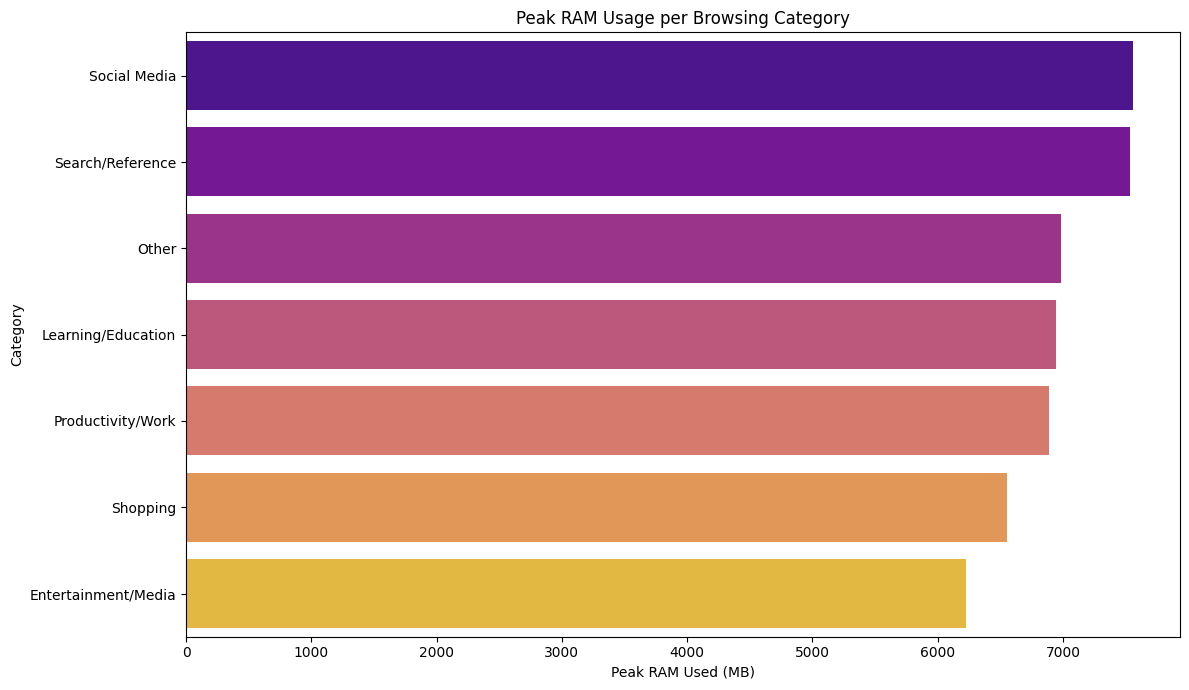

In [53]:
# Sort categories by peak RAM usage for better visualization
category_ram_stats_sorted = category_ram_stats.sort_values(by='peak_used_mb', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='peak_used_mb', y='category', data=category_ram_stats_sorted, palette='plasma')
plt.title('Peak RAM Usage per Browsing Category')
plt.xlabel('Peak RAM Used (MB)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Clustering

For k = 2, Silhouette Score is: 0.2714
For k = 3, Silhouette Score is: 0.2798
For k = 4, Silhouette Score is: 0.2542
For k = 5, Silhouette Score is: 0.2600
For k = 6, Silhouette Score is: 0.2694
For k = 7, Silhouette Score is: 0.2557
For k = 8, Silhouette Score is: 0.2465


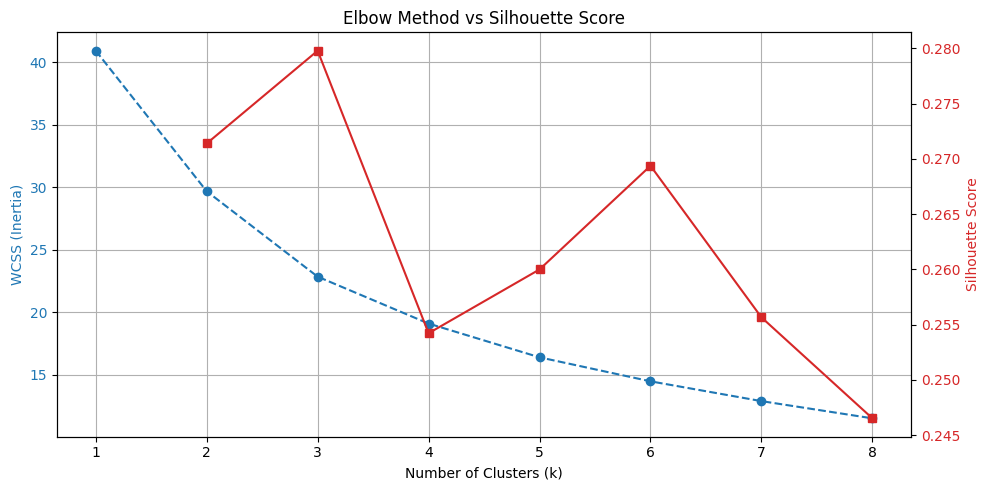

In [54]:
# 1. Combine session_summary_df and session_ram_stats
session_features = pd.merge(session_summary_df, session_ram_stats, on='session_id', how='left')

# 2. Engineer additional features (e.g., hour of day for session start)
session_features['session_start_hour'] = session_features['session_start'].dt.hour
session_features['session_start_dayofweek'] = session_features['session_start'].dt.dayofweek

# 3. Select features for clustering
features_for_clustering = [
    'session_duration_minutes', 'page_count', 'unique_domains',
    'unique_categories', 'domain_switches', 'category_switches',
    'avg_time_per_page_seconds', 'mean_used_mb', 'peak_used_mb',
    'mean_usage_percent', 'peak_usage_percent', 'session_start_hour',
    'session_start_dayofweek'
]

X = session_features[features_for_clustering].copy()

# Handle potential NaN values resulting from merging or calculations (e.g., for very short sessions)
X = X.fillna(0)

# 4. Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 5. Determine optimal number of clusters using Elbow and Silhouette Methods
wcss = []
silhouette_scores = []
k_range = range(2, min(len(X_scaled), 9)) # Silhouette score requires at least 2 clusters

# Calculate WCSS for k=1 first (since silhouette score cannot be calculated for k=1)
kmeans_1 = KMeans(n_clusters=1, init='k-means++', random_state=42, n_init=10)
kmeans_1.fit(X_scaled)
wcss.append(kmeans_1.inertia_)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # 1. Save Elbow metric
    wcss.append(kmeans.inertia_)

    # 2. Save Silhouette metric
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"For k = {i}, Silhouette Score is: {score:.4f}")

# Plotting both metrics side-by-side for comparison
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Elbow Method (WCSS)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(range(1, min(len(X_scaled), 9)), wcss, marker='o', linestyle='--', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Elbow Method vs Silhouette Score')
ax1.grid(True)

# Plot Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()



In [55]:
k_optimal=3

# 6. Apply KMeans clustering with the chosen k
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
session_features['cluster'] = kmeans.fit_predict(X_scaled)

# 7. Analyze cluster characteristics (interpretation rules)
print(f"\n--- Cluster Analysis (k={k_optimal}) ---")
cluster_summary = (session_features.groupby('cluster').agg({
    'session_duration_minutes': ['mean', 'std'],
    'page_count': ['mean', 'std'],
    'unique_domains': ['mean', 'std'],
    'unique_categories': ['mean', 'std'],
    'mean_used_mb': ['mean', 'std'],
    'peak_used_mb': ['mean', 'std'],
    'mean_usage_percent': ['mean', 'std'],
    'peak_usage_percent': ['mean', 'std'],
    'session_start_hour': [('mode', lambda x: x.mode()[0]), 'count'],
    'session_start_dayofweek': [('mode', lambda x: x.mode()[0]), 'count'],
    'primary_category': [('mode', lambda x: x.mode()[0]), 'count']
}))

display(cluster_summary)


--- Cluster Analysis (k=3) ---


session_duration_minutes             page_count              \
                            mean         std       mean         std   
cluster                                                               
0                     360.246667  145.644931  1019.6000  410.405545   
1                     155.384375   87.219874   446.5625  245.366656   
2                      96.900667   75.960524   279.2000  214.713181   

        unique_domains            unique_categories           mean_used_mb  \
                  mean        std              mean       std         mean   
cluster                                                                      
0              61.7000  21.166273            5.2000  1.032796  4742.403731   
1              20.5625  13.366469            4.9375  1.340087  3796.953186   
2              13.7600   8.709573            3.6400  1.287116  5448.469841   

                     ... mean_usage_percent           peak_usage_percent  \
                std  ...               mean       std               mean   
cluster              ...                                                   
0        796.596107  ...          57.890638  9.724009            82.2720   
1        405.451436  ...          46.349571  4.949318            61.7900   
2        437.016841  ...          66.509700  5.334631            79.3848   

                  session_start_hour       session_start_dayofweek        \
              std               mode count                    mode count   
cluster                                                                    
0        8.466745                 16    10                       2    10   
1        8.301056                  1    16                       0    16   
2        6.220835                 12    25                       1    25   

         primary_category        
                     mode count  
cluster                          
0        Search/Reference    10  
1        Search/Reference    16  
2        Search/Reference    25  

[3 rows x 22 columns]

/tmp/ipykernel_1131/2529893336.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_flat.index, y=feature, data=cluster_summary_flat, palette='viridis')
/tmp/ipykernel_1131/2529893336.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_flat.index, y=feature, data=cluster_summary_flat, palette='viridis')
/tmp/ipykernel_1131/2529893336.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_flat.index, y=feature, data=cluster_summary_flat, palette='viridis')
/tmp/ipykernel_1131/2529893336.py:

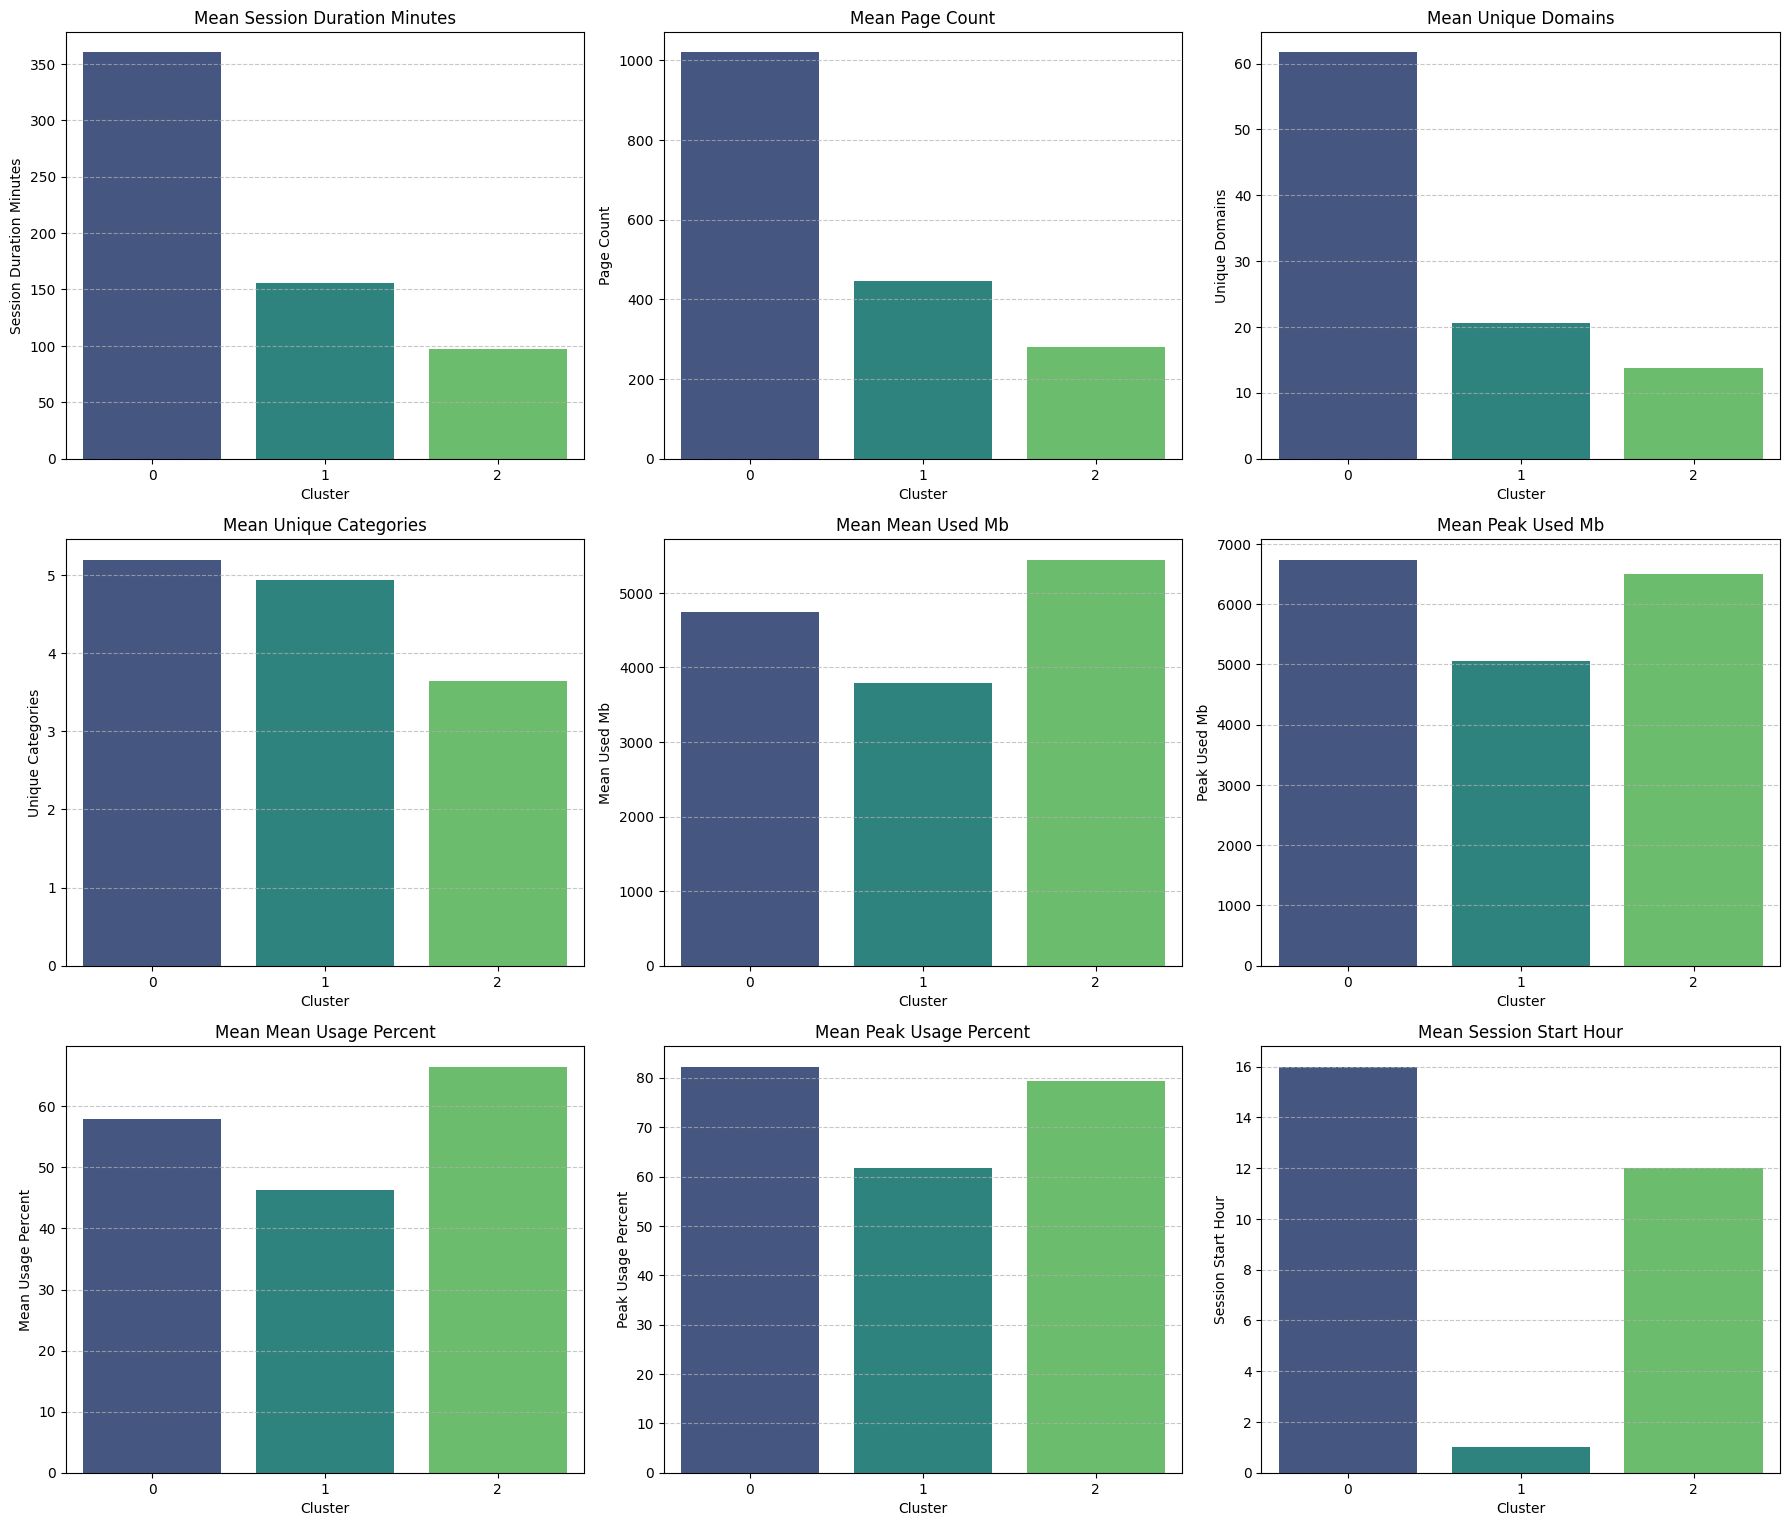

In [56]:
# Flatten the multi-index columns of cluster_summary for easier plotting
cluster_summary_flat = cluster_summary.copy()
cluster_summary_flat.columns = ['_'.join(col).strip() for col in cluster_summary_flat.columns.values]

# Get the list of features for which we want to plot means
# Exclude 'primary_category_mode' and 'session_start_dayofweek_mode' as they are categorical/mode
plot_features = [
    col for col in cluster_summary_flat.columns
    if col.endswith('_mean') and
    not col.startswith(('primary_category', 'session_start_dayofweek', 'session_start_hour'))
]
# Add mode for session_start_hour
plot_features.append('session_start_hour_mode')

plt.figure(figsize=(18, 20))
for i, feature in enumerate(plot_features):
    plt.subplot(round(len(plot_features)/3) + 1, 3, i + 1)
    sns.barplot(x=cluster_summary_flat.index, y=feature, data=cluster_summary_flat, palette='viridis')
    plt.title(f'Mean {feature.replace("_mean", "").replace("_mode", "").replace("_", " ").title()}')
    plt.xlabel('Cluster')
    plt.ylabel(feature.replace('_mean', '').replace('_mode', '').replace('_', ' ').title())
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


These plots provide a clear visual comparison of how each cluster differs across various metrics. For instance, you can see which clusters have higher average session durations, more unique domains, or greater RAM usage.

Now, let's look at the primary category and session start day/hour modes for each cluster to further refine our interpretation.

/tmp/ipykernel_1131/3975922059.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_flat.index, y='primary_category_mode', data=cluster_summary_flat, palette='tab10')
/tmp/ipykernel_1131/3975922059.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary_flat.index, y='session_start_dayofweek_mode_name', data=cluster_summary_flat, palette='tab10')


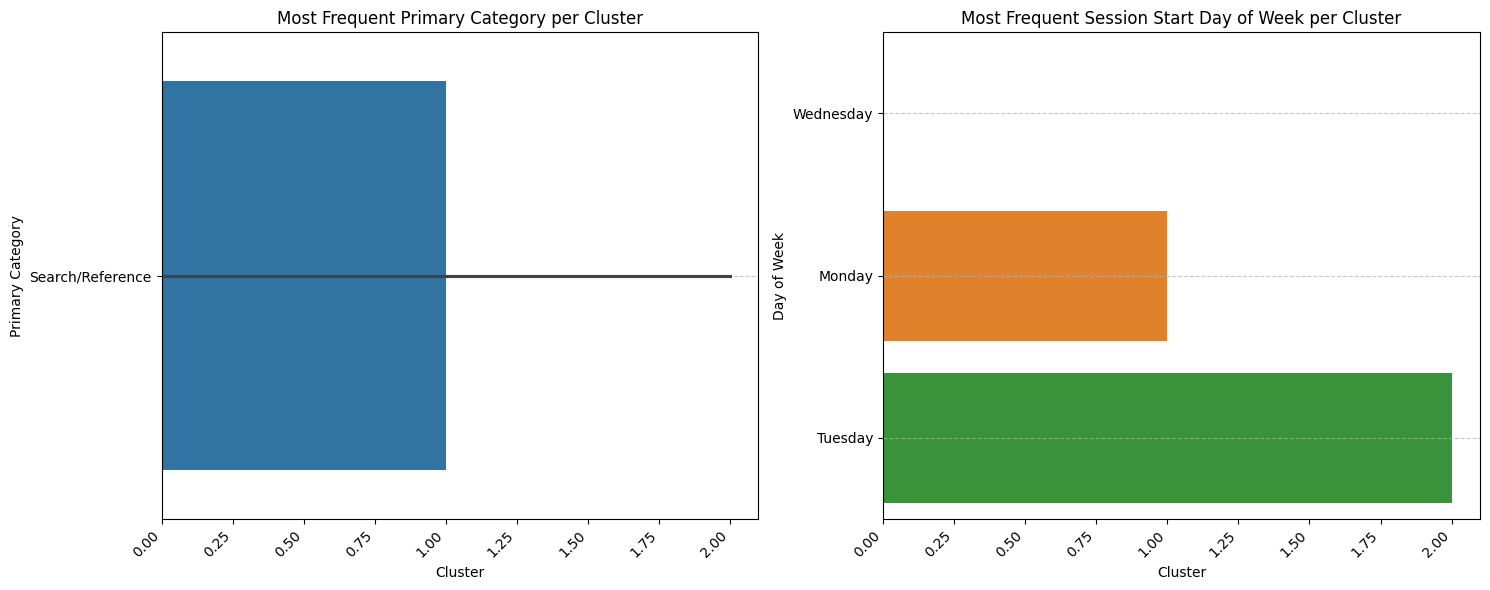

In [57]:
# Plotting categorical features (mode)
plt.figure(figsize=(15, 6))

# Primary Category
plt.subplot(1, 2, 1)
sns.barplot(x=cluster_summary_flat.index, y='primary_category_mode', data=cluster_summary_flat, palette='tab10')
plt.title('Most Frequent Primary Category per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Primary Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Session Start Day of Week
plt.subplot(1, 2, 2)
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cluster_summary_flat['session_start_dayofweek_mode_name'] = cluster_summary_flat['session_start_dayofweek_mode'].map(lambda x: day_names[x])
sns.barplot(x=cluster_summary_flat.index, y='session_start_dayofweek_mode_name', data=cluster_summary_flat, palette='tab10')
plt.title('Most Frequent Session Start Day of Week per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Day of Week')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Deep Learning

In [58]:
unique_categories = chrome_data['category'].unique()
category_to_id = {category: i for i, category in enumerate(unique_categories)}
id_to_category = {i: category for category, i in category_to_id.items()}

# Map categories in chrome_data to numerical IDs
chrome_data['category_id'] = chrome_data['category'].map(category_to_id)

# Create sequences of category IDs for each session.
session_sequences = chrome_data.groupby('session_id')['category_id'].apply(list).tolist()

# Prepare input-output pairs (X, y) with a fixed sequence length.
fixed_sequence_length = 5

X_sequences = []
y_next_category = []

for seq in session_sequences:
    if len(seq) > fixed_sequence_length:
        for i in range(len(seq) - fixed_sequence_length):
            X_sequences.append(seq[i:i+fixed_sequence_length]) # Fixed-length input sequence
            y_next_category.append(seq[i+fixed_sequence_length]) # The next category to predict

# For fixed-length sequences, np.array directly creates the correct shape (no need for custom padding function)
X_padded = np.array(X_sequences)

# Convert to PyTorch tensors
X_tensor = torch.LongTensor(X_padded)
y_tensor = torch.LongTensor(y_next_category)

# Update max_sequence_length to the new fixed length for clarity and consistency with model input
max_sequence_length = fixed_sequence_length

print(f"Number of sequences for training: {len(X_sequences)}")
print(f"Fixed sequence length: {max_sequence_length}")
print(f"Number of unique categories: {len(unique_categories)}")
print(f"Sample X_tensor shape: {X_tensor.shape}")
print(f"Sample y_tensor shape: {y_tensor.shape}")

# Split data into training and testing sets
try:
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor)
except ValueError:
    print("Warning: Stratification not possible due to insufficient samples in some classes. Splitting without stratification.")
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)


# Create a custom Dataset
class CategorySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CategorySequenceDataset(X_train, y_train)
test_dataset = CategorySequenceDataset(X_test, y_test)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Number of sequences for training: 24069
Fixed sequence length: 5
Number of unique categories: 7
Sample X_tensor shape: torch.Size([24069, 5])
Sample y_tensor shape: torch.Size([24069])


In [59]:
class CategoryPredictor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, output_dim, dropout_prob=0.5):
        super(CategoryPredictor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden_state = hidden[-1, :, :]
        out = self.dropout(last_hidden_state)
        out = self.fc(out)
        return out

# Model parameters
vocab_size = len(unique_categories) # Number of unique categories
embed_dim = 128                     # Dimension of category embeddings
hidden_dim = 256                    # Number of features in the LSTM hidden state
num_layers = 2                      # Number of recurrent layers
output_dim = vocab_size             # Number of output classes (next category prediction)

# Instantiate the model
model = CategoryPredictor(vocab_size, embed_dim, hidden_dim, num_layers, output_dim)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print("\nLSTM model defined and moved to device:", device)
print("\n",model)



LSTM model defined and moved to device: cpu

 CategoryPredictor(
  (embedding): Embedding(7, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=256, out_features=7, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)



Starting model training...
Epoch 1/10, Train Loss: 0.5150, Test Accuracy: 0.8779
Epoch 2/10, Train Loss: 0.4596, Test Accuracy: 0.8781
Epoch 3/10, Train Loss: 0.4540, Test Accuracy: 0.8774
Epoch 4/10, Train Loss: 0.4527, Test Accuracy: 0.8783
Epoch 5/10, Train Loss: 0.4514, Test Accuracy: 0.8783
Epoch 6/10, Train Loss: 0.4497, Test Accuracy: 0.8783
Epoch 7/10, Train Loss: 0.4484, Test Accuracy: 0.8785
Epoch 8/10, Train Loss: 0.4470, Test Accuracy: 0.8783
Epoch 9/10, Train Loss: 0.4461, Test Accuracy: 0.8760
Epoch 10/10, Train Loss: 0.4427, Test Accuracy: 0.8774

Training complete.

Detailed Classification Report on Test Set:
                     precision    recall  f1-score   support

 Learning/Education       0.86      0.88      0.87       347
  Productivity/Work       0.77      0.69      0.73        74
   Search/Reference       0.88      0.90      0.89      2149
       Social Media       0.93      0.94      0.94      1112
              Other       0.83      0.79      0.81      1072

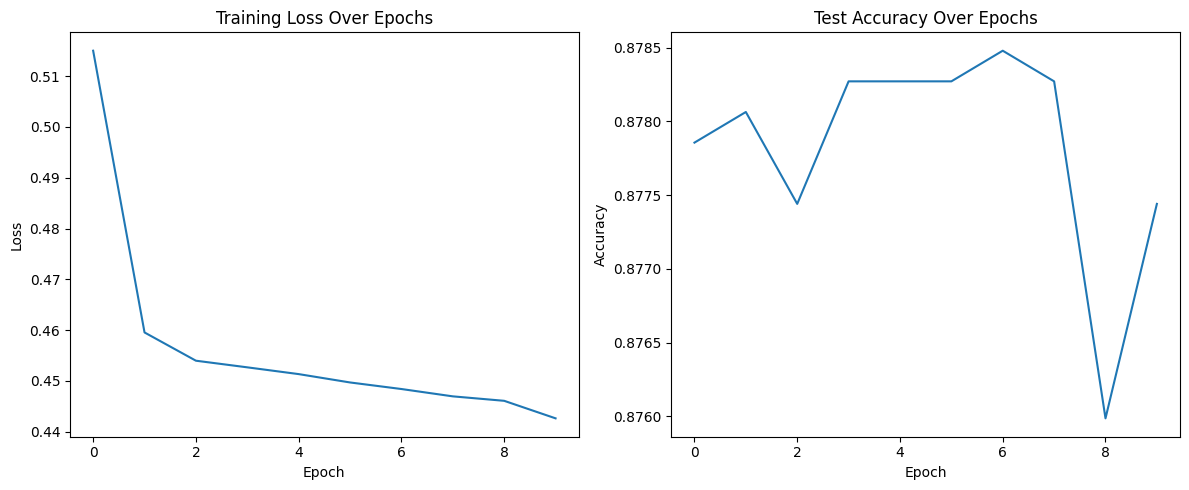

In [60]:
# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10

train_losses = []
test_accuracies = []

print("\nStarting model training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluate on the test set
    model.eval() # Set model to evaluation mode
    correct_predictions = 0
    total_predictions = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad(): # Disable gradient calculation during evaluation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    test_accuracy = correct_predictions / total_predictions
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

print("\nTraining complete.")

# Evaluation
print("\nDetailed Classification Report on Test Set:")
print(classification_report(all_labels, all_predictions, target_names=unique_categories))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(test_accuracies)
plt.title('Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## Evaluation Metrics: Deep Learning (LSTM)

This section evaluates the performance of the LSTM model for next-category prediction.

                     precision    recall  f1-score   support

 Learning/Education       0.86      0.88      0.87       347
  Productivity/Work       0.77      0.69      0.73        74
   Search/Reference       0.88      0.90      0.89      2149
       Social Media       0.93      0.94      0.94      1112
              Other       0.83      0.79      0.81      1072
           Shopping       0.64      0.73      0.68        51
Entertainment/Media       1.00      0.78      0.88         9

           accuracy                           0.88      4814
          macro avg       0.85      0.81      0.83      4814
       weighted avg       0.88      0.88      0.88      4814



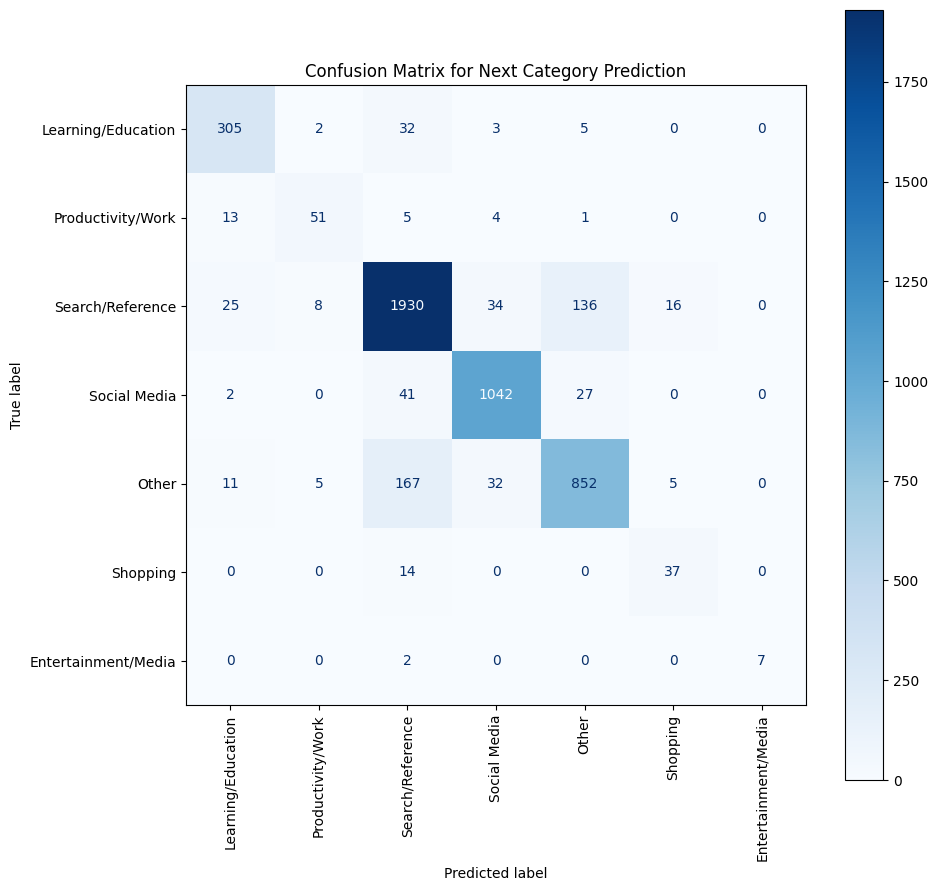


Baseline Accuracy (Most Common Category): 0.4464
LSTM Model Test Accuracy: 0.8774
The LSTM model performs better than the most-common-category baseline.


In [61]:
# Next-category accuracy / macro F1-score
print(classification_report(all_labels, all_predictions, target_names=unique_categories))

# Confusion matrix for categories
cm = confusion_matrix(all_labels, all_predictions)
fig_cm, ax_cm = plt.subplots(figsize=(10, 10))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_categories)
display_cm.plot(cmap=plt.cm.Blues, ax=ax_cm)
plt.title('Confusion Matrix for Next Category Prediction')
plt.xticks(rotation=90)
plt.show()

# A simple baseline model that always predicts the most frequent category
most_common_category_id = chrome_data['category_id'].mode()[0]

baseline_predictions = [most_common_category_id] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"\nBaseline Accuracy (Most Common Category): {baseline_accuracy:.4f}")
print(f"LSTM Model Test Accuracy: {test_accuracies[-1]:.4f}")

if test_accuracies[-1] > baseline_accuracy:
    print("The LSTM model performs better than the most-common-category baseline.")
else:
    print("The LSTM model does NOT perform better than the most-common-category baseline.")


# Recommendation Engine + Reporting

In [62]:
# Function to get LSTM predictions
def get_lstm_recommendation(last_n_categories, model, id_to_category, category_to_id, fixed_sequence_length, device='cpu'):
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        # Convert category names to IDs and pad/truncate to fixed_sequence_length
        encoded_sequence = [category_to_id.get(cat, category_to_id.get('Other', 0)) for cat in last_n_categories]

        # Pad or truncate the sequence to the fixed length
        if len(encoded_sequence) < fixed_sequence_length:
            padded_sequence = [category_to_id.get('Other', 0)] * (fixed_sequence_length - len(encoded_sequence)) + encoded_sequence
        else:
            padded_sequence = encoded_sequence[-fixed_sequence_length:]

        input_tensor = torch.LongTensor(padded_sequence).unsqueeze(0).to(device) # Add batch dimension
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_id = torch.argmax(probabilities, dim=1).item()

        return id_to_category.get(predicted_id, 'Unknown')

# Rule-based recommendations
def get_rule_based_recommendations(primary_category_for_session, category_ram_stats, cluster_id=None):
    recommendations = []

    # Rule 1: High RAM Usage Alert
    high_ram_categories = category_ram_stats[category_ram_stats['peak_usage_percent'] > 70]['category'].tolist()
    if primary_category_for_session in high_ram_categories:
        recommendations.append(f"Consider optimizing your browsing for '{primary_category_for_session}' to reduce RAM usage.")

    # Rule 2: Productivity Boost (if in a 'work' cluster, or if the primary category suggests work)
    if cluster_id == 1 or primary_category_for_session == 'Productivity/Work':
        recommendations.append("You seem to be in a productive work session. Check out new tools for 'Productivity/Work'.")

    # Rule 3 for demonstration, if not passing full session_data (If primary category is entertainment, suggest education)
    if primary_category_for_session in ['Social Media', 'Entertainment/Media']:
        recommendations.append("You've been engaged in entertainment. Perhaps a quick browse of 'Learning/Education' content?")
    elif primary_category_for_session in ['Learning/Education', 'Productivity/Work']:
        recommendations.append("Great focus! Consider a short break or some 'Entertainment/Media' to relax.")

    return recommendations

# Overall Browsing Summary
total_visits = chrome_data.shape[0]
num_sessions = session_summary_df.shape[0]
most_frequent_category_overall = chrome_data['category'].mode()[0]
avg_session_duration = session_summary_df['session_duration_minutes'].mean()

report_lines = []
report_lines.append("## Personal Browsing Activity Report\n")
report_lines.append(f"### Overall Summary (based on {len(chrome_data)} browsing events)\n")
report_lines.append(f"- Total browsing events analyzed: {total_visits}")
report_lines.append(f"- Total sessions identified: {num_sessions}")
report_lines.append(f"- Most frequent browsing category: **{most_frequent_category_overall}**")
report_lines.append(f"- Average session duration: **{avg_session_duration:.2f} minutes**\n")

report_lines.append("### Key Insights from Data Analysis\n")

report_lines.append("#### RAM Usage by Category:")
for index, row in category_ram_stats.sort_values(by='peak_usage_percent', ascending=False).head(3).iterrows():
    report_lines.append(f"- **{row['category']}**: Peak RAM usage at {row['peak_used_mb']:.2f} MB ({row['peak_usage_percent']:.2f}%)\n")

report_lines.append("#### Session Clustering Analysis:\n")
cluster_info = cluster_summary_flat[['session_duration_minutes_mean', 'page_count_mean', 'mean_used_mb_mean', 'primary_category_mode', 'session_start_hour_mode', 'session_start_dayofweek_mode_name']].copy()
cluster_info.columns = ['Avg Duration (min)', 'Avg Page Count', 'Avg RAM (MB)', 'Primary Category', 'Avg Start Hour', 'Avg Start Day']
report_lines.append("Interpreting clusters based on average metrics:")
report_lines.append(cluster_info.to_markdown(numalign="left", stralign="left"))
report_lines.append("\n")

report_lines.append("### Sample Recommendations\n")

last_session_id = chrome_data['session_id'].max()
last_session_data = chrome_data[chrome_data['session_id'] == last_session_id]

if not last_session_data.empty:
    report_lines.append(f"#### Recommendations for your last session (Session ID: {last_session_id}):\n")

    # LSTM Recommendation
    last_n_categories = last_session_data['category'].tail(max_sequence_length).tolist()
    lstm_rec = get_lstm_recommendation(last_n_categories, model, id_to_category, category_to_id, fixed_sequence_length, device)
    report_lines.append(f"- Based on your recent browsing, you might be interested in more **{lstm_rec}** content (LSTM Model prediction).")

    # Rule-based Recommendations
    session_cluster = session_features[session_features['session_id'] == last_session_id]['cluster'].iloc[0]
    # Get the primary_category for the last session directly from session_features
    primary_category_last_session = session_features[session_features['session_id'] == last_session_id]['primary_category'].iloc[0]

    rule_recs = get_rule_based_recommendations(primary_category_last_session, category_ram_stats, session_cluster)
    if rule_recs:
        for rec in rule_recs:
            report_lines.append(f"- {rec}")
    else:
        report_lines.append("- No specific rule-based recommendations at this moment for this session.\n")
else:
    report_lines.append("No recent browsing data to generate specific session recommendations.")

# Print the full report
final_report = "\n".join(report_lines)
print(final_report)


## Personal Browsing Activity Report

### Overall Summary (based on 24321 browsing events)

- Total browsing events analyzed: 24321
- Total sessions identified: 51
- Most frequent browsing category: **Search/Reference**
- Average session duration: **166.88 minutes**

### Key Insights from Data Analysis

#### RAM Usage by Category:
- **Social Media**: Peak RAM usage at 7555.90 MB (92.24%)

- **Search/Reference**: Peak RAM usage at 7534.70 MB (91.98%)

- **Other**: Peak RAM usage at 6985.70 MB (85.27%)

#### Session Clustering Analysis:

Interpreting clusters based on average metrics:
| cluster   | Avg Duration (min)   | Avg Page Count   | Avg RAM (MB)   | Primary Category   | Avg Start Hour   | Avg Start Day   |
|:----------|:---------------------|:-----------------|:---------------|:-------------------|:-----------------|:----------------|
| 0         | 360.247              | 1019.6           | 4742.4         | Search/Reference   | 16               | Wednesday       |
| 1         | 155